<a href="https://colab.research.google.com/github/pritthwishGC/AIML-Lab-Sem-5/blob/main/Lab_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install networkx matplotlib

BFS Traversal Order: A -> B -> C -> D -> E -> F
DFS Traversal Order: A -> B -> D -> E -> C -> F


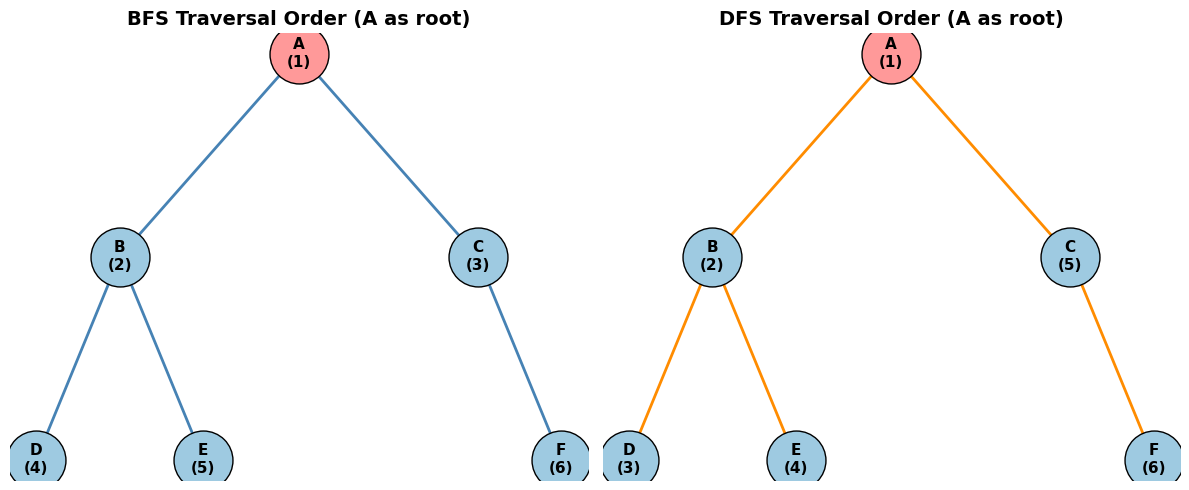

In [ ]:
from collections import deque
import matplotlib.pyplot as plt

graph = {
    'A': ['B', 'C'],
    'B': ['A', 'D', 'E'],
    'C': ['A', 'F'],
    'D': ['B'],
    'E': ['B'],
    'F': ['C']
}

def bfs(graph, start):
    visited = {start}
    order = []
    queue = deque([start])
    while queue:
        node = queue.popleft()
        order.append(node)
        for neighbor in graph[node]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)
    return order

def dfs(graph, start, visited=None, order=None):
    if visited is None:
        visited = set()
        order = []
    visited.add(start)
    order.append(start)
    for neighbor in graph[start]:
        if neighbor not in visited:
            dfs(graph, neighbor, visited, order)
    return order

bfs_order = bfs(graph, 'A')
dfs_order = dfs(graph, 'A')

print("BFS Traversal Order:", " -> ".join(bfs_order))
print("DFS Traversal Order:", " -> ".join(dfs_order))

edges = [('A', 'B'), ('A', 'C'), ('B', 'D'), ('B', 'E'), ('C', 'F')]

pos = {
    'A': (0, 3),
    'B': (-1.5, 2),
    'C': (1.5, 2),
    'D': (-2.2, 1),
    'E': (-0.8, 1),
    'F': (2.2, 1)
}

def draw_traversal(ax, order, title, edge_color):
    for (u, v) in edges:
        x_vals = [pos[u][0], pos[v][0]]
        y_vals = [pos[u][1], pos[v][1]]
        ax.plot(x_vals, y_vals, color=edge_color, linewidth=2, zorder=1)
    rank = {node: i + 1 for i, node in enumerate(order)}
    for node, (x, y) in pos.items():
        face_color = '#ff9999' if node == order[0] else '#9ecae1'
        ax.scatter(x, y, s=1800, color=face_color, edgecolors='black', zorder=2)
        ax.text(x, y, f"{node}\n({rank[node]})", ha='center', va='center',
                fontsize=11, fontweight='bold', zorder=3)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
draw_traversal(axes[0], bfs_order, "BFS Traversal Order (A as root)", edge_color='steelblue')
draw_traversal(axes[1], dfs_order, "DFS Traversal Order (A as root)", edge_color='darkorange')
plt.tight_layout()
plt.show()

In [1]:
from collections import deque

CAP_A = 4
CAP_B = 3
GOAL = 2

def get_next_states(state):
    a, b = state
    results = []
    results.append(((CAP_A, b), f"Fill Jug A ({a},{b}) -> ({CAP_A},{b})"))
    results.append(((a, CAP_B), f"Fill Jug B ({a},{b}) -> ({a},{CAP_B})"))
    results.append(((0, b), f"Empty Jug A ({a},{b}) -> (0,{b})"))
    results.append(((a, 0), f"Empty Jug B ({a},{b}) -> ({a},0)"))
    pour_to_b = min(a, CAP_B - b)
    new_a, new_b = a - pour_to_b, b + pour_to_b
    results.append(((new_a, new_b), f"Pour A into B ({a},{b}) -> ({new_a},{new_b})"))
    pour_to_a = min(b, CAP_A - a)
    new_a2, new_b2 = a + pour_to_a, b - pour_to_a
    results.append(((new_a2, new_b2), f"Pour B into A ({a},{b}) -> ({new_a2},{new_b2})"))
    return results

def bfs_water_jug(start, goal):
    visited = {start}
    queue = deque([(start, [])])
    while queue:
        state, path = queue.popleft()
        a, b = state
        if a == goal or b == goal:
            return path, state
        for next_state, move in get_next_states(state):
            if next_state not in visited:
                visited.add(next_state)
                queue.append((next_state, path + [move]))
    return None, None

start_state = (0, 0)
solution, final_state = bfs_water_jug(start_state, GOAL)

print(f"Starting State: {start_state}")
print(f"Goal: Measure {GOAL} litres in either jug")
print(f"Minimum number of steps: {len(solution)}")
print(f"Final State Reached: {final_state}")
print("Step-by-step solution:")
for i, move in enumerate(solution, 1):
    print(f"{i}. {move}")

Starting State: (0, 0)
Goal: Measure 2 litres in either jug
Minimum number of steps: 4
Final State Reached: (4, 2)
Step-by-step solution:
1. Fill Jug B (0,0) -> (0,3)
2. Pour B into A (0,3) -> (3,0)
3. Fill Jug B (3,0) -> (3,3)
4. Pour B into A (3,3) -> (4,2)


In [2]:
graph = {
    'A': ['B', 'D'],
    'B': ['A', 'C'],
    'C': ['B', 'D'],
    'D': ['A', 'C'],
    'E': ['F'],
    'F': ['E'],
    'G': []
}

def dfs_route_exists(graph, start, target, visited=None):
    if visited is None:
        visited = set()
    if start == target:
        return True
    visited.add(start)
    for neighbor in graph[start]:
        if neighbor not in visited:
            if dfs_route_exists(graph, neighbor, target, visited):
                return True
    return False

def dfs_collect(graph, start, visited):
    stack = [start]
    component = []
    while stack:
        node = stack.pop()
        if node not in visited:
            visited.add(node)
            component.append(node)
            for neighbor in graph[node]:
                if neighbor not in visited:
                    stack.append(neighbor)
    return component

def find_connected_components(graph):
    visited = set()
    components = []
    for node in graph:
        if node not in visited:
            component = dfs_collect(graph, node, visited)
            components.append(sorted(component))
    return components

pairs_to_check = [('A', 'D'), ('A', 'E'), ('E', 'F'), ('G', 'A')]
for city1, city2 in pairs_to_check:
    exists = dfs_route_exists(graph, city1, city2)
    print(f"Route between {city1} and {city2}: {exists}")

components = find_connected_components(graph)
print("Connected Components:")
for i, component in enumerate(components, 1):
    print(f"Component {i}: {component}")

Route between A and D: True
Route between A and E: False
Route between E and F: True
Route between G and A: False
Connected Components:
Component 1: ['A', 'B', 'C', 'D']
Component 2: ['E', 'F']
Component 3: ['G']
